# Dimensional Method: CS-01 TAS

**Purpose**: characterise the Tele Assistance System dimensionally for every
adaptation (`baseline`, `s1`, `s2`, `aggregate`). For each artifact, PyDASA
derives Pi-groups from the 10 relevant variables (3 FDUs: `T`, `S`, `D`
meaning Time / Structure / Data), then four operationally meaningful
coefficients are built from them:

- $\theta = L/K$ &nbsp; **Occupancy** (queue fill ratio)
- $\sigma = W\lambda/K$ &nbsp; **Stall** (Little's-law residual; blocking)
- $\eta = \chi K/(\mu c)$ &nbsp; **Effective-yield** (utilisation headroom)
- $\phi = M_{act}/M_{buf}$ &nbsp; **Memory-usage** (buffer fill)

Outputs go under `data/results/dimensional/<scenario>/<profile>.json` and
figures under `data/img/dimensional/<scenario>/`.

**Equivalent CLI**:

```bash
python -m src.methods.dimensional --adaptation baseline
python -m src.methods.dimensional --adaptation s1 --profile opti
python -m src.methods.dimensional --adaptation s2 --profile opti
python -m src.methods.dimensional --adaptation aggregate --profile opti
```


In [1]:
%matplotlib inline

from pathlib import Path

import pandas as pd

from src.dimensional import (coefs_to_net,
                             coefs_to_nodes)
from src.methods.dimensional import run
from src.view import (plot_dim_topology,
                      plot_node_diffmap,
                      plot_node_heatmap,
                      plot_arch_bars,
                      plot_arch_delta)

# adaptation axis for the matrix
ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# figure output root for this method
IMG_ROOT = Path("data/img/dimensional")

# white-noise level baked into the robust dimensional run (section 1); 0.05 = 5%
# relative Gaussian noise on the M/M/c/K independent variables (lambda, mu, epsilon),
# seeded from the dimensional method config so the perturbed run stays reproducible.
NOISE = 0.05

# Human-readable scenario labels for plot titles / legends.
DISPLAY = {
    "baseline": "No Adaptation",
    "s1": "S1: Retry",
    "s2": "S2: Select-Reliable",
    "aggregate": "S1 & S2",
}

# label map for the four derived coefficients (\mathbf so Greek renders bold under matplotlib mathtext)
COEF_LABELS = {
    "theta": r"$\mathbf{\theta}$",
    "sigma": r"$\mathbf{\sigma}$",
    "eta": r"$\mathbf{\eta}$",
    "phi": r"$\mathbf{\phi}$",
}

## 1. Run the dimensional method on every adaptation

`run(adp=a, wrt=True, noise=NOISE, noise_scope="coefficients")` loads the
resolved `NetCfg`, builds one `AnalysisEngine` per artifact, derives 7
Pi-groups, applies the 4 coefficient specs from
`data/config/method/dimensional.json`, and runs a symbolic sensitivity pass.
Result written to `data/results/dimensional/<scenario>/<profile>.json`.

This is the **robust** dimensional solution: a seeded 5% relative Gaussian
white noise (`NOISE`) disturbs the M/M/c/K independent variables ($\lambda$,
$\mu$, $\varepsilon$) so the four derived coefficients ($\theta$, $\sigma$,
$\eta$, $\phi$) carry the input uncertainty. `noise_scope="coefficients"`
confines the noise to the dimensional coefficient pass: the operational layer
(`nodes` / `network`) and the R1 / R2 verdict are solved on the clean inputs,
so the persisted verdict still matches the analytic + stochastic methods
exactly (`06-comparison.ipynb` stays congruent). The seed comes from
`data/config/method/dimensional.json`, so the run is reproducible.

In [2]:
results = {
    a: run(adp=a,
           wrt=True,
           noise=NOISE,
           noise_scope="coefficients") for a in ADAPTATIONS
}

In [3]:
# Unpack the per-adaptation pieces used in every later cell. The operational layer
# (cfgs / nodes / nets / reqs) is clean (mirrors the analytic + stochastic notebooks);
# the dimensional view (dim_nodes / dim_nets) carries the seeded 5% coefficient noise.
cfgs = {a: results[a]["config"] for a in ADAPTATIONS}
nodes = {a: results[a]["nodes"] for a in ADAPTATIONS}
nets = {a: results[a]["network"] for a in ADAPTATIONS}
reqs = {a: results[a]["requirements"] for a in ADAPTATIONS}

dim_nodes = {a: coefs_to_nodes(results[a]) for a in ADAPTATIONS}
dim_nets = {a: coefs_to_net(results[a]) for a in ADAPTATIONS}

print(f"Solved {len(results)} adaptations (robust, {int(NOISE * 100)}% coefficient noise); " + "wrote JSONs under data/results/dimensional/")

Solved 4 adaptations (robust, 5% coefficient noise); wrote JSONs under data/results/dimensional/


In [4]:
for a in ADAPTATIONS:
    print(f"{a:>10} -> profile={cfgs[a].profile}  scenario={cfgs[a].scenario}  "
          f"artifacts={len(results[a]['artifacts'])}")

  baseline -> profile=dflt  scenario=baseline  artifacts=13
        s1 -> profile=opti  scenario=s1  artifacts=13
        s2 -> profile=opti  scenario=s2  artifacts=13
 aggregate -> profile=opti  scenario=aggregate  artifacts=13


## 2. Network-wide coefficient summary

One row per adaptation. Aggregation is the **mean** across the 13 (or 16)
artifacts of that scenario; see `coefs_to_net(agg="median")` for
the robust view.


In [5]:
rows = []
for a in ADAPTATIONS:
    row = {"adaptation": a}
    row.update(dim_nets[a].iloc[0].to_dict())
    rows.append(row)

pd.DataFrame(rows).set_index("adaptation")

,nodes,theta,sigma,eta,phi
adaptation,,,,,
baseline,13.0,0.035216,0.035220,5.039714,0.035216
s1,13.0,0.043016,0.043035,5.537864,0.050211
s2,13.0,0.026297,0.026297,4.329223,0.026297
aggregate,13.0,0.030847,0.030851,4.740337,0.030847


## 3. Per-node coefficient snapshot (baseline)

Reference cloud before any adaptation. Under the uniform baseline init
($L_{mean}=6$, $K_{mean}=10$, $M_{act}=L\delta$, $M_{buf}=K\delta$), $\theta$
and $\phi$ collapse to the same value $0.6$ on every artifact. $\sigma$ and
$\eta$ vary with the per-artifact service rate and error probability.


In [6]:
dim_nodes["baseline"][["key", "name", "type", "theta", "sigma", "eta", "phi"]]

,key,name,type,theta,sigma,eta,phi
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,0.053499,0.053499,7.379373,0.053499
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,0.035673,0.035673,5.813895,0.035673
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,0.016658,0.016658,3.366981,0.016658
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,0.058949,0.058950,8.734669,0.058949
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,0.011904,0.011904,2.743277,0.011904
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,0.114340,0.114379,12.142812,0.114340
6,AS_{1},Alarm Service 1,M/M/s/K,0.005601,0.005601,1.459410,0.005601
7,AS_{2},Alarm Service 2,M/M/s/K,0.009022,0.009022,2.098373,0.009022
8,AS_{3},Alarm Service 3,M/M/s/K,0.002624,0.002624,0.763931,0.002624
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,0.029587,0.029587,5.140653,0.029587


## 4. Dimensionless topology (per adaptation)

Architecture diagram mirrored from the analytic method, but node colouring
and labels switch to the four dimensionless coefficients
($	heta, \sigma, \eta, \phi$) instead of queue metrics. Node colour
encodes $\sigma$ (Stall, queueing share of capacity); the per-node label
shows the artifact key plus $	heta$ (Occupancy). Full per-node coefficient
table sits below the graph. Every adaptation gets its own topology.png
under data/img/dimensional/<adp>/.


In [7]:
# remove FAIL node to simplify renders (mirrors 01-analytic)
# FAIL_{1} (the absorbing failure sink) stays in the SOLVE for availability, but is dropped from
# the topology figure. dim_nodes already excludes it (coefs_to_nodes reads result["artifacts"],
# 13 nodes); the routing carries FAIL as the last node, so slice it off for the diagram.
routs = {a: cfgs[a].routing[:-1, :-1] for a in ADAPTATIONS}

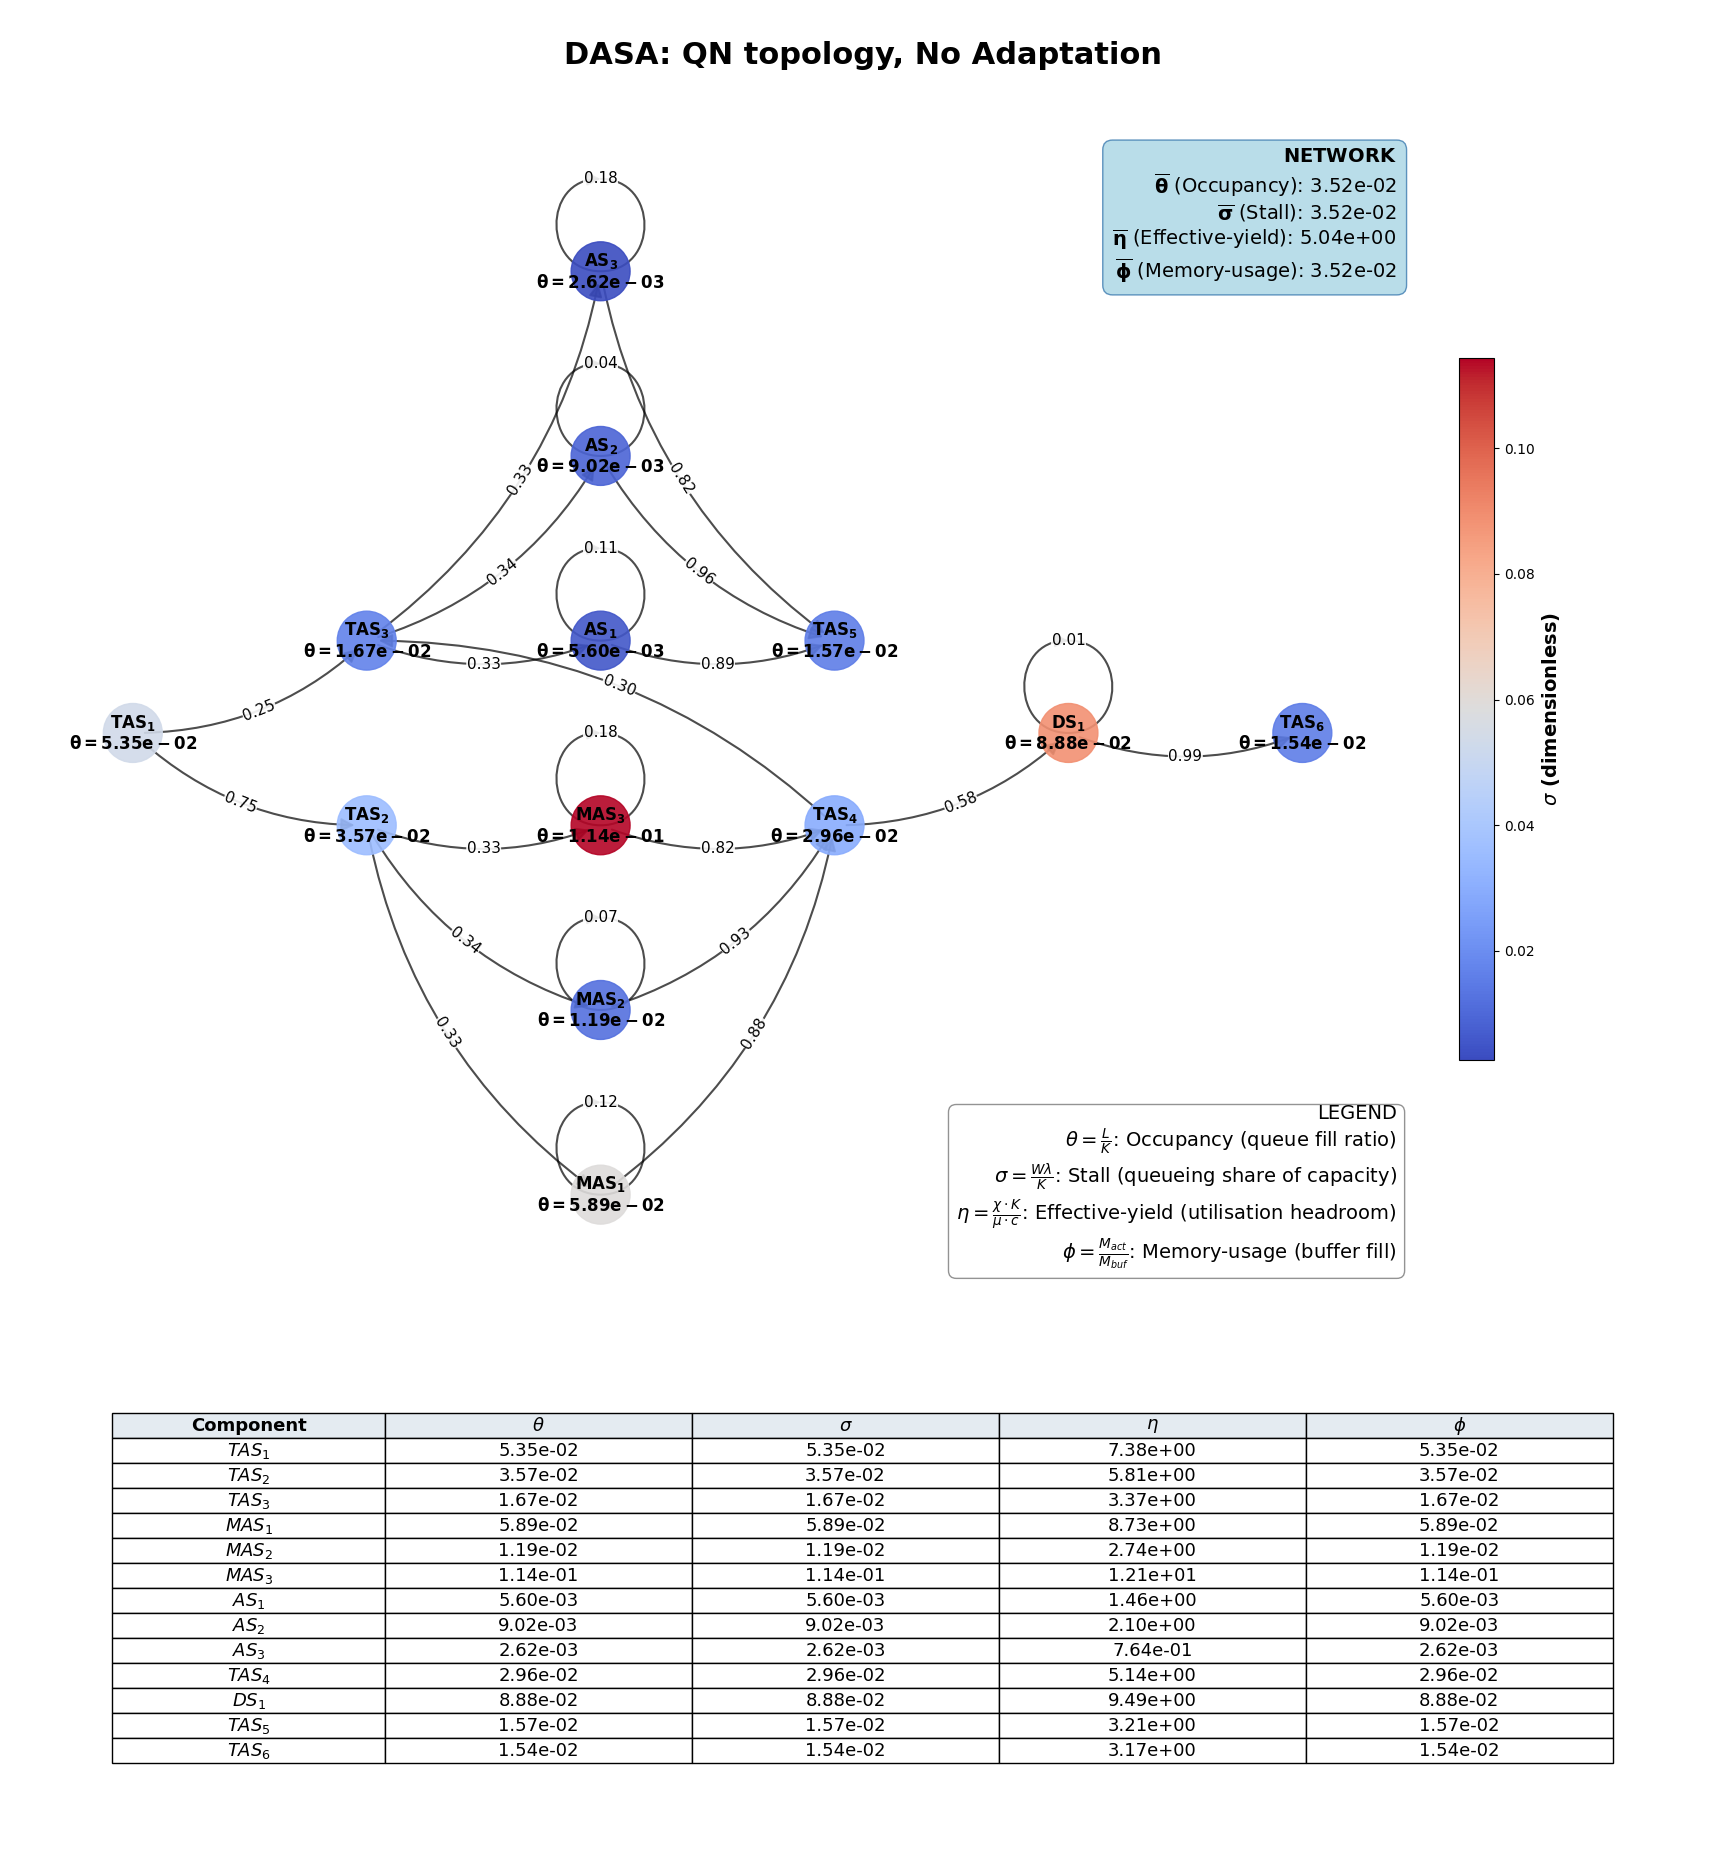

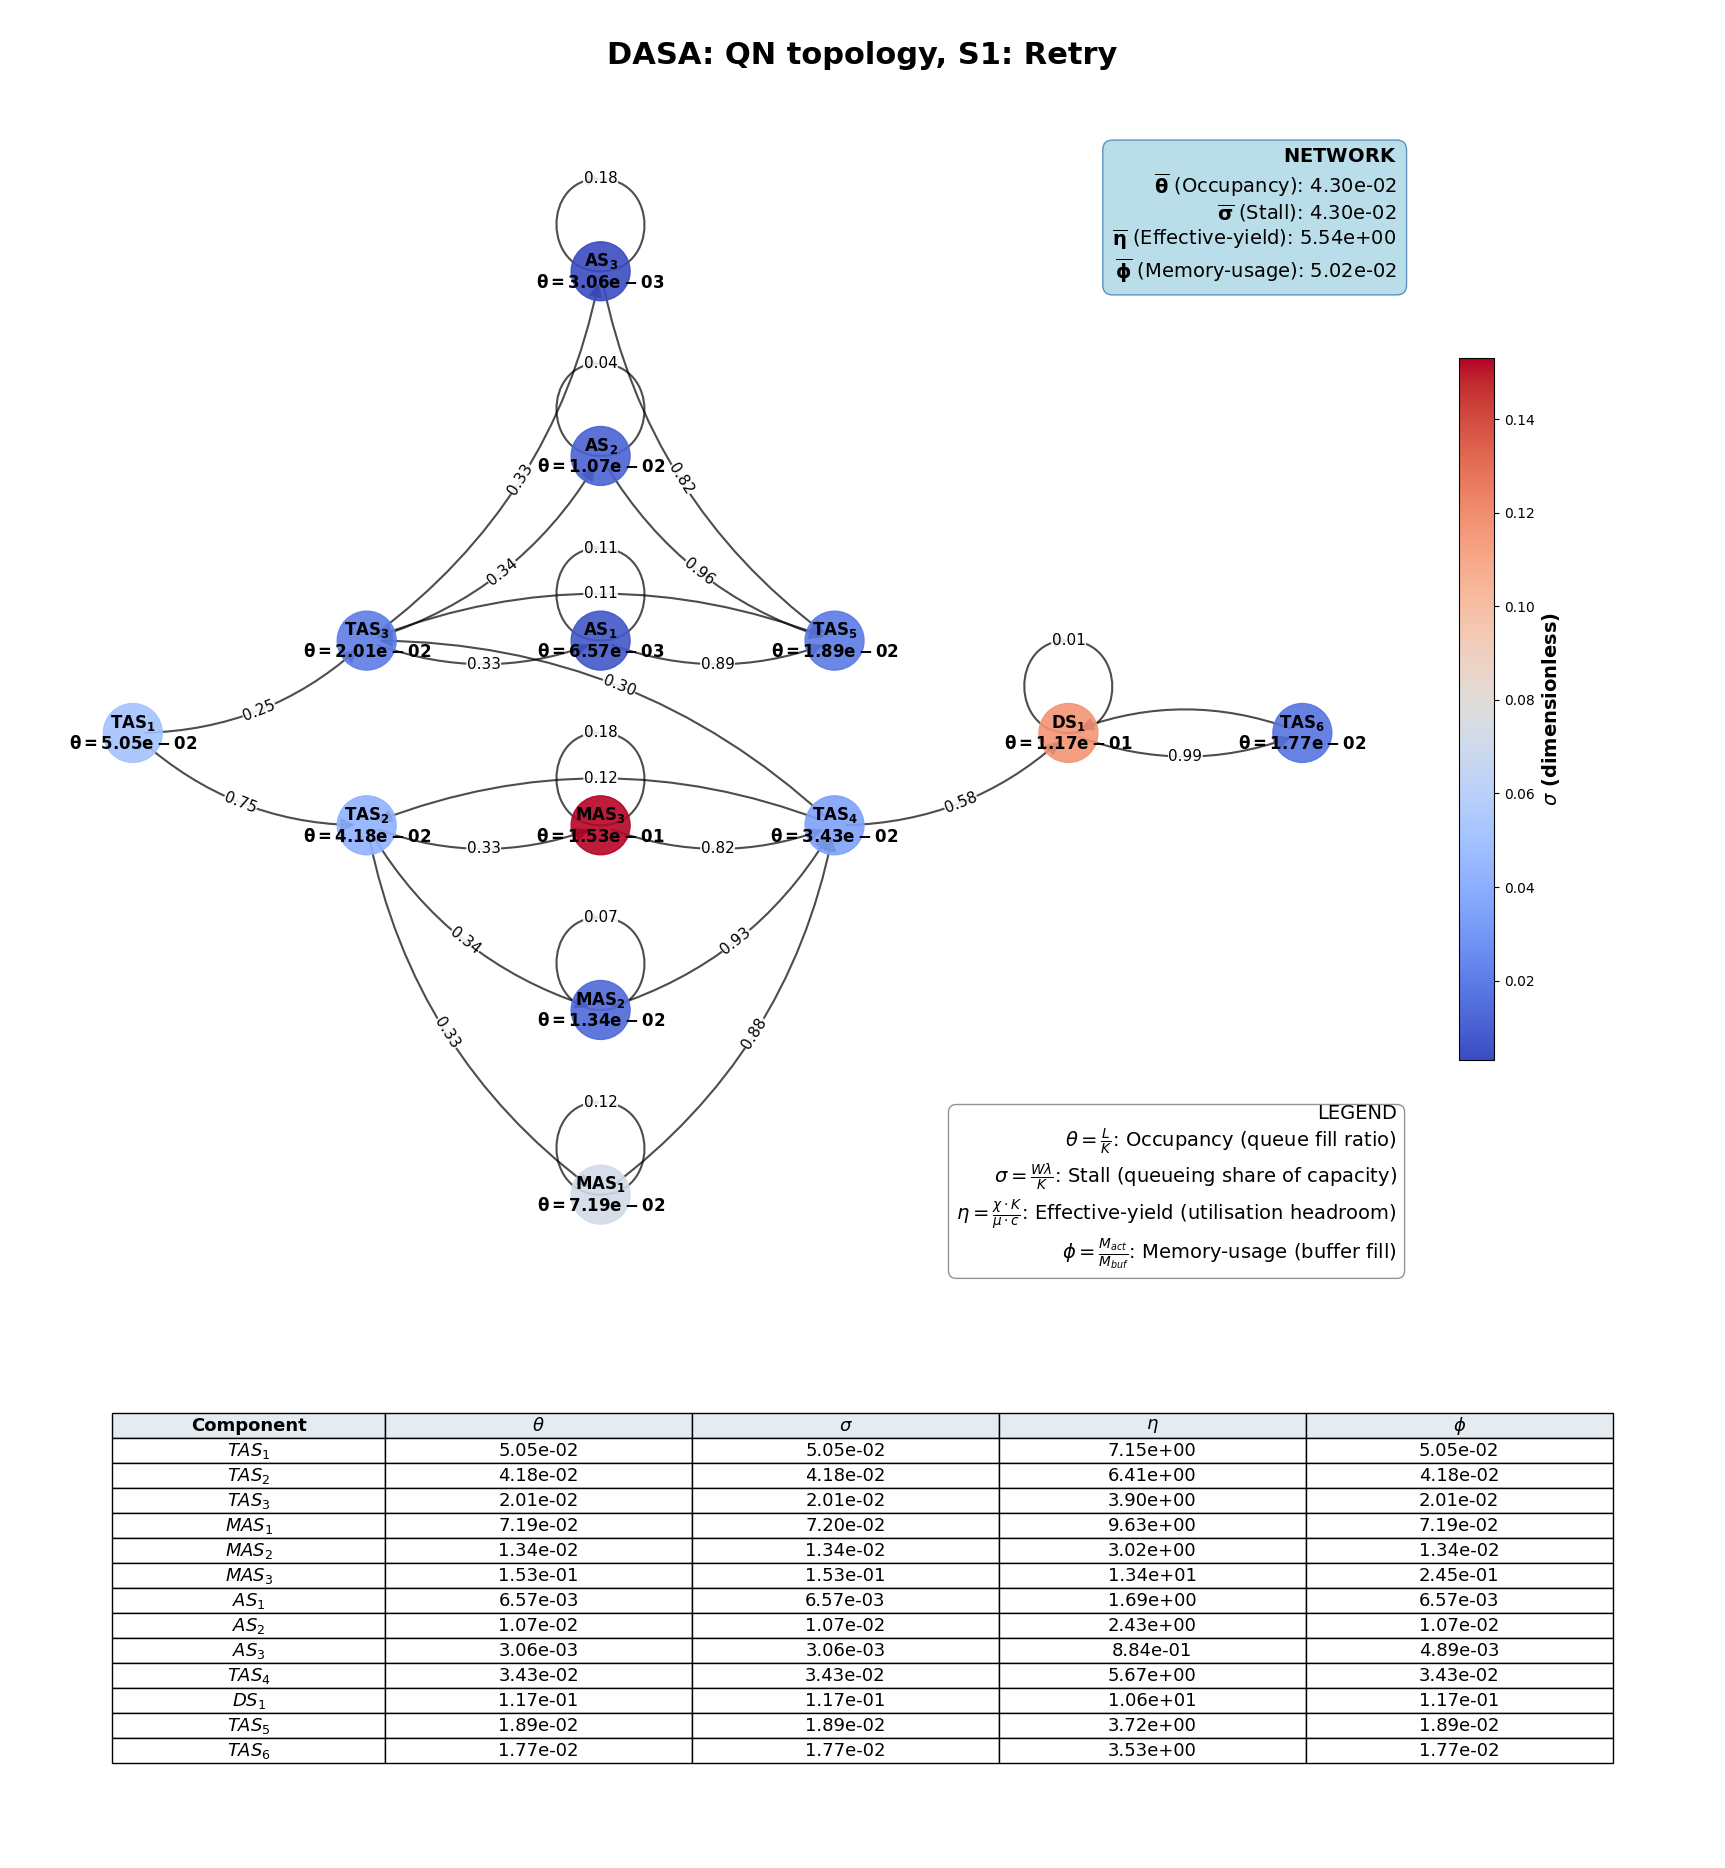

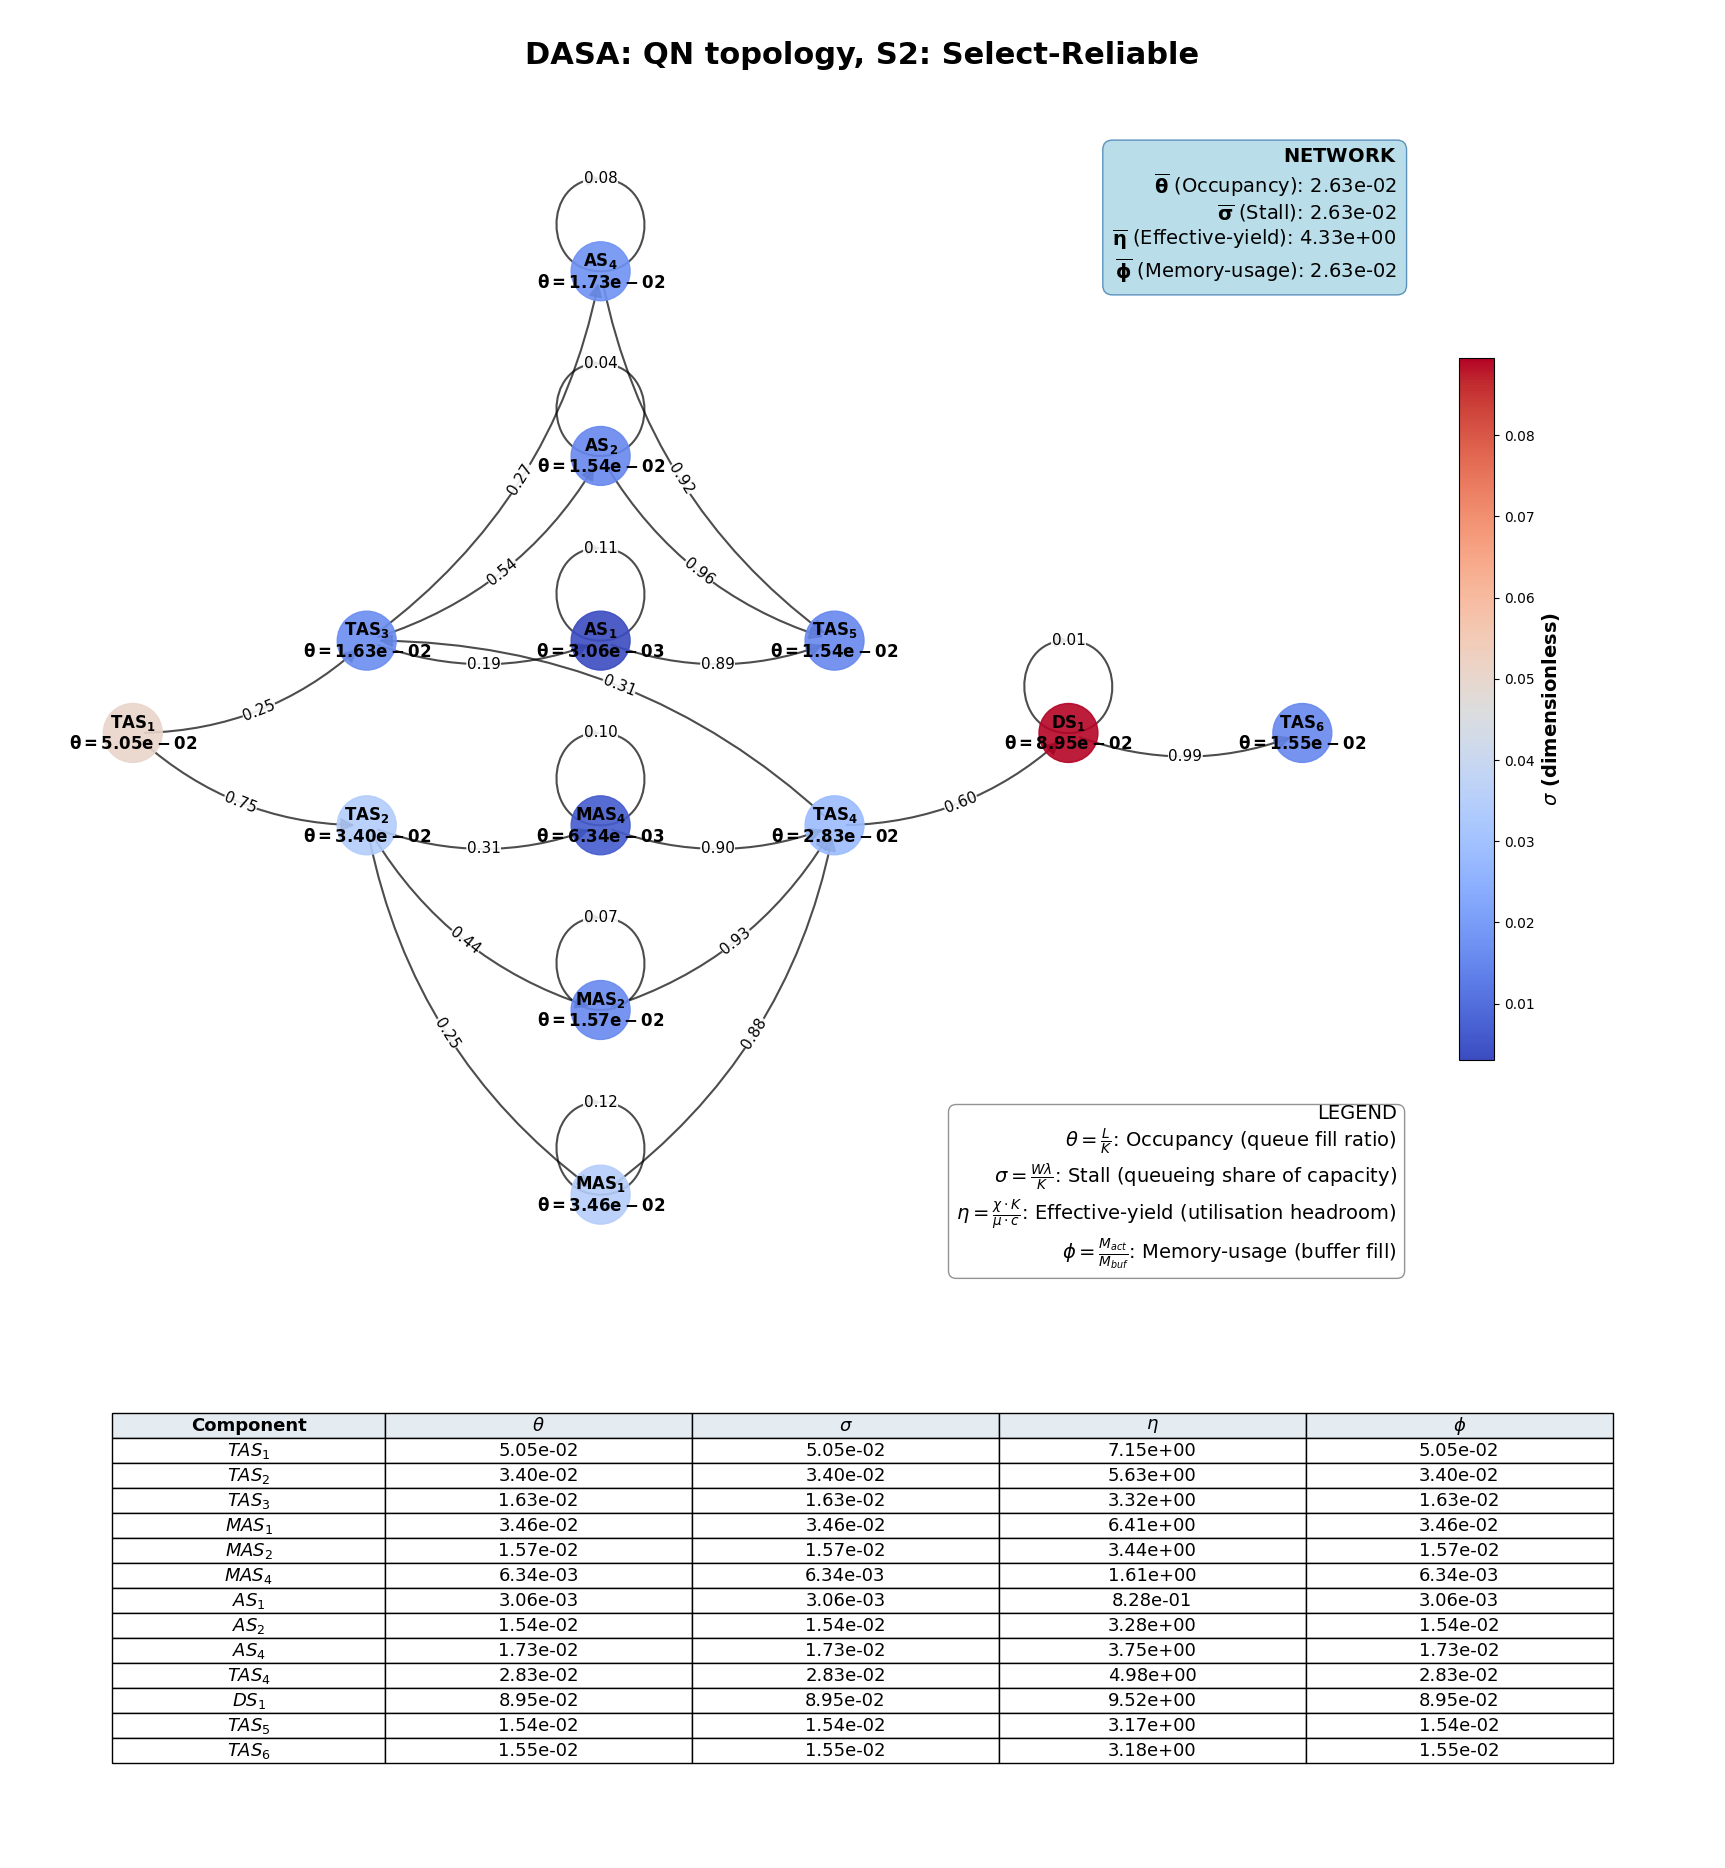

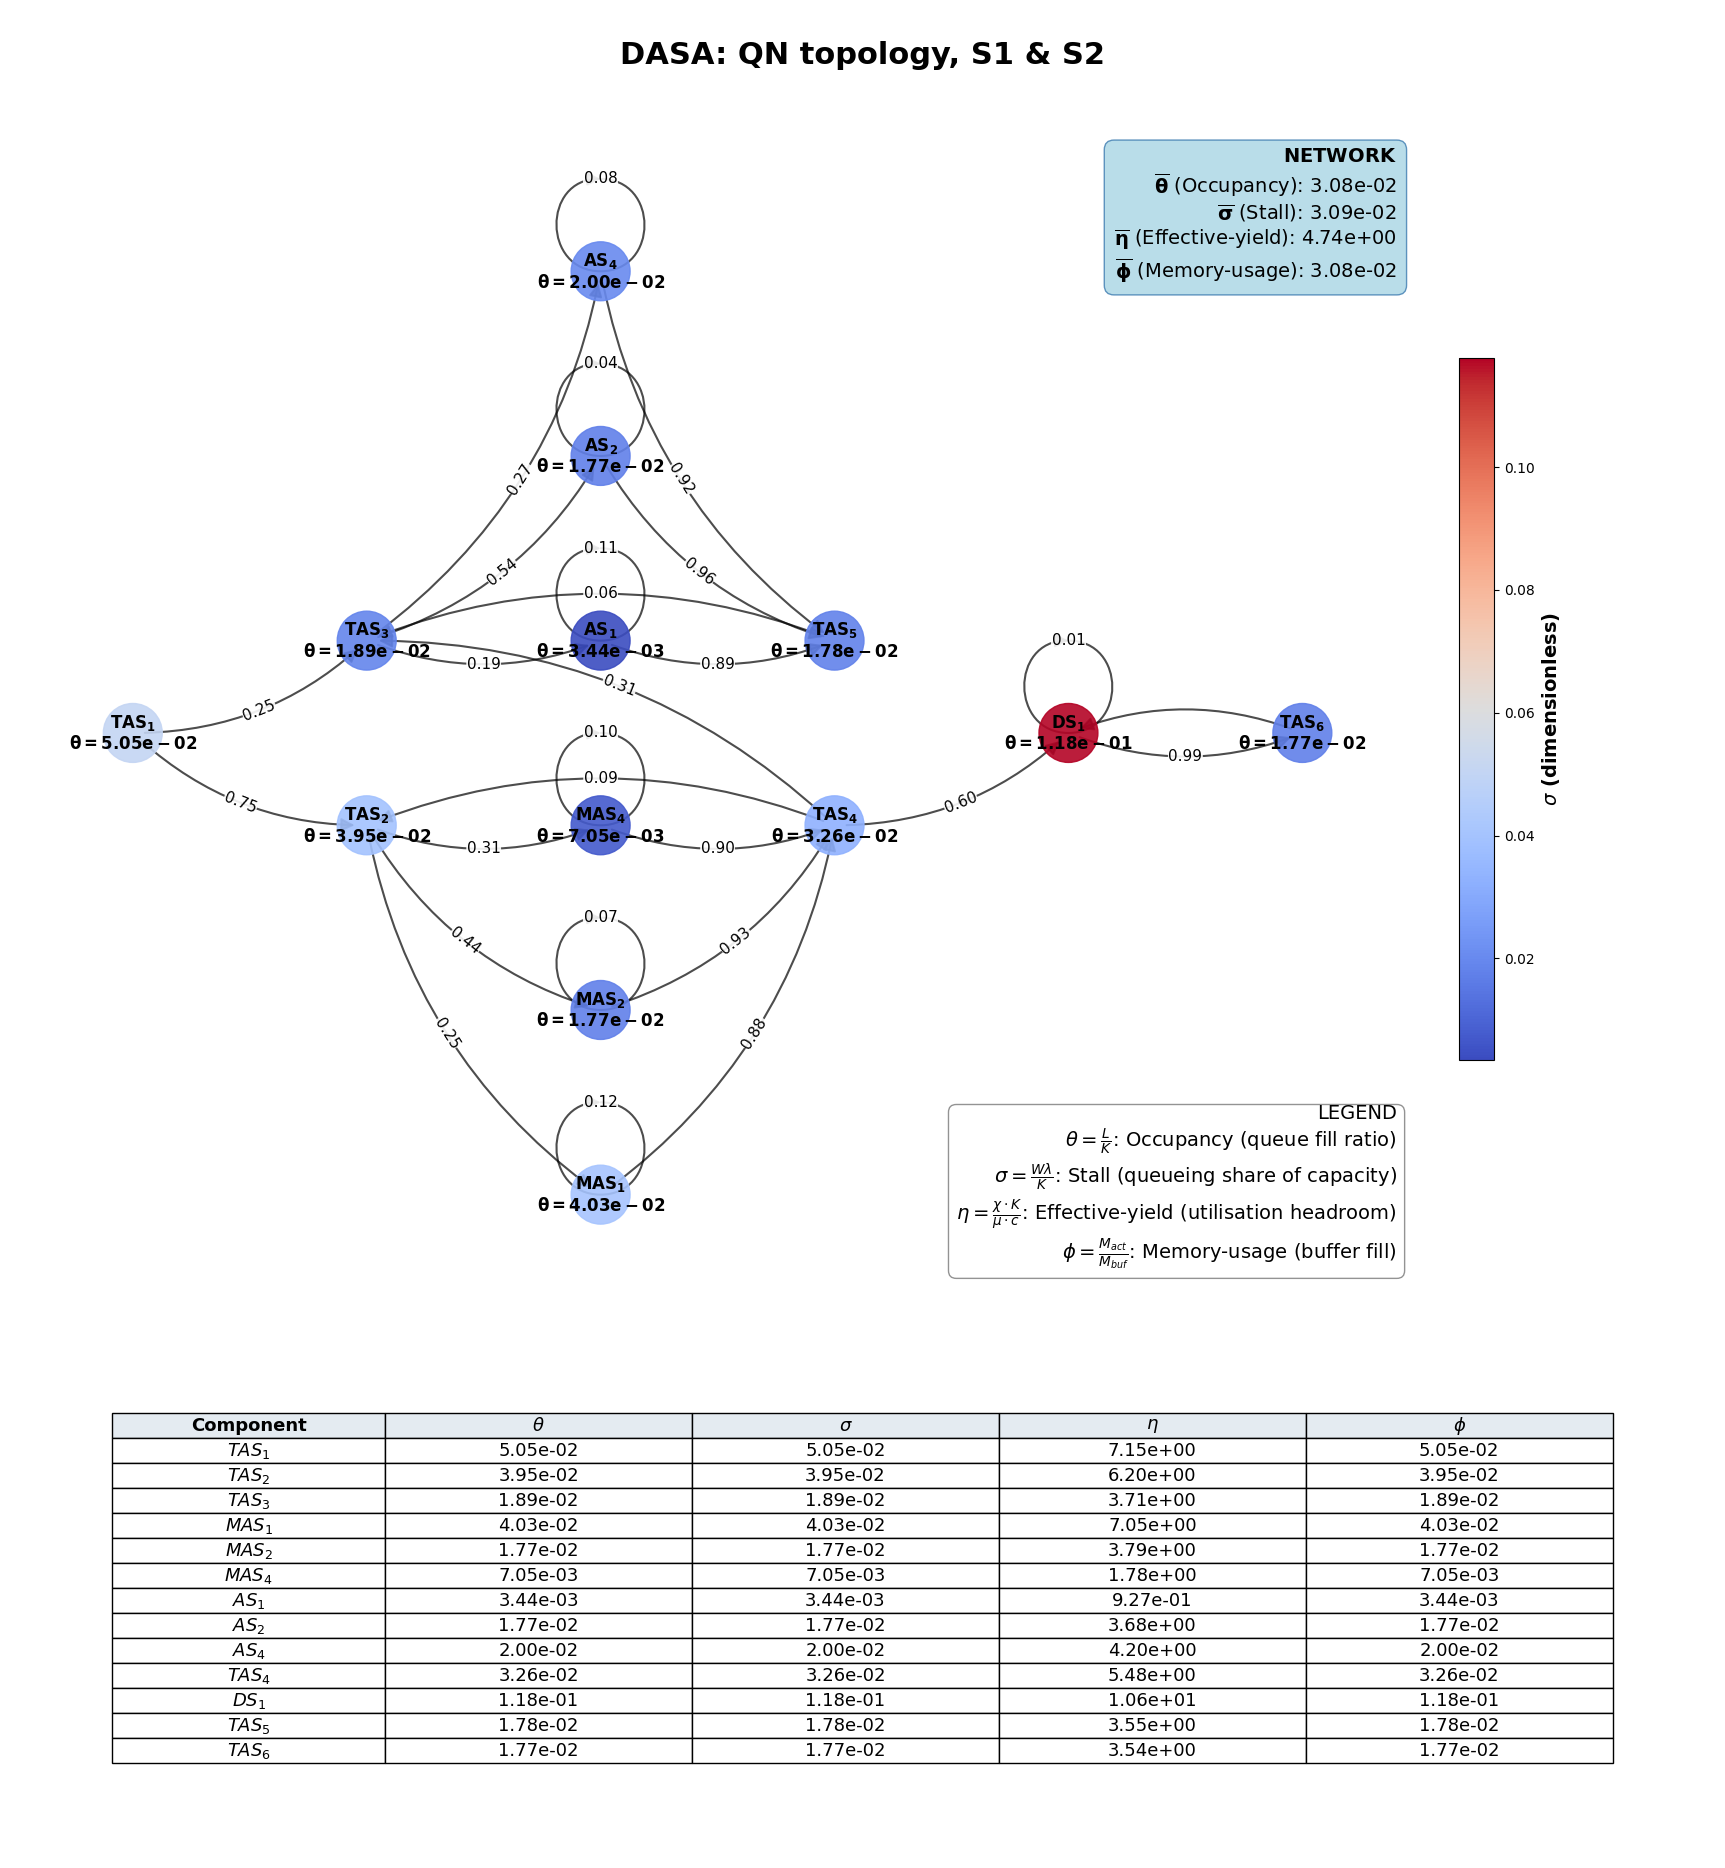

In [8]:
# routs is the FAIL-filtered routing from the cell above; dim_nodes is already 13-node.
for a in ADAPTATIONS:
    plot_dim_topology(
        rout=routs[a],
        nds=dim_nodes[a],
        color_by="sigma",
        title=f"DASA: QN topology, {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="topology.png",
    )

## 5. Per-node coefficient heatmap (before vs after)

One row = one artifact. One column = one coefficient ($\theta$, $\sigma$,
$\eta$, $\phi$). Colour scaled per-column across ALL scenarios so the same
cell is comparable across adaptations. One subplot per adaptation.


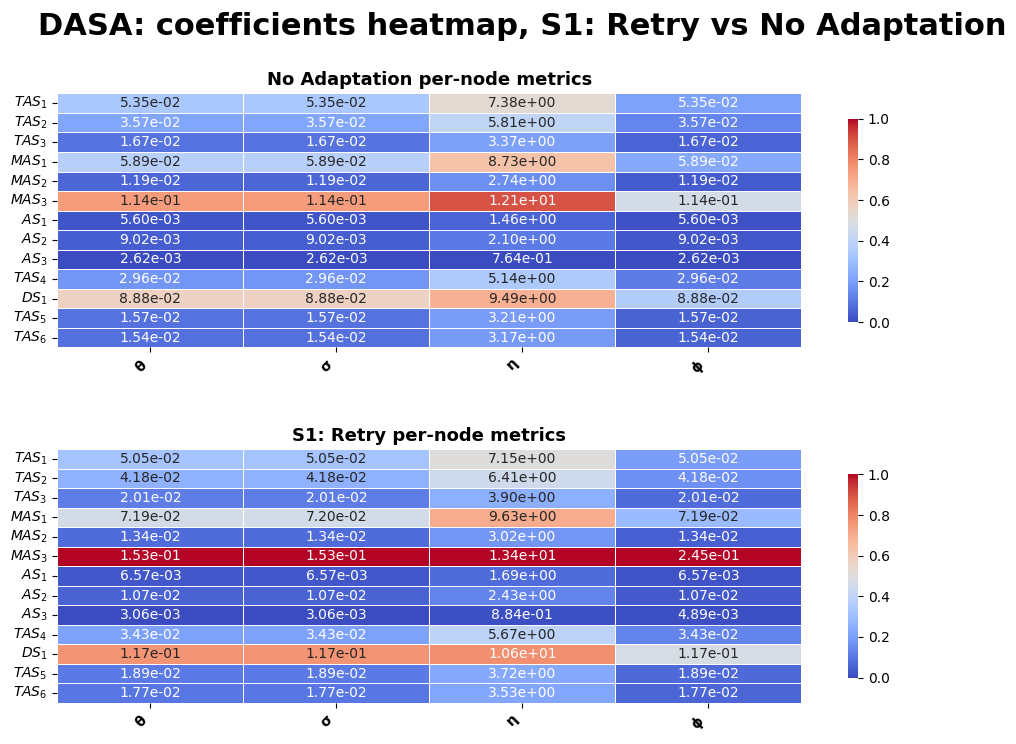

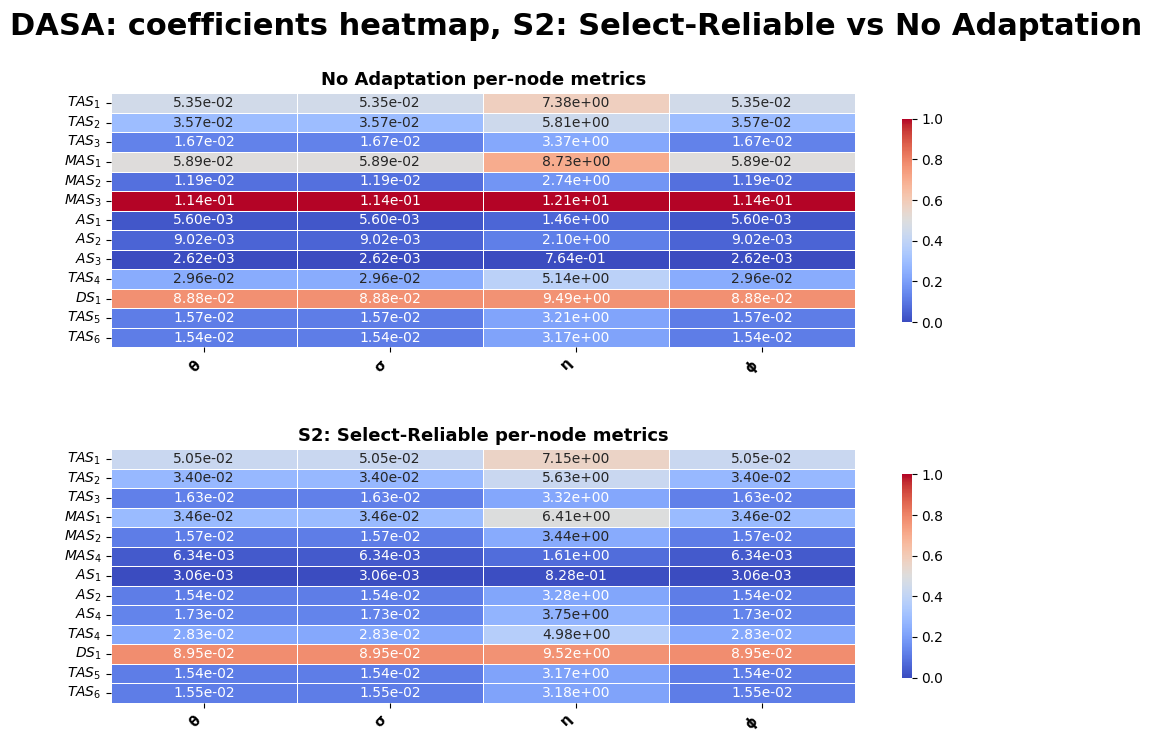

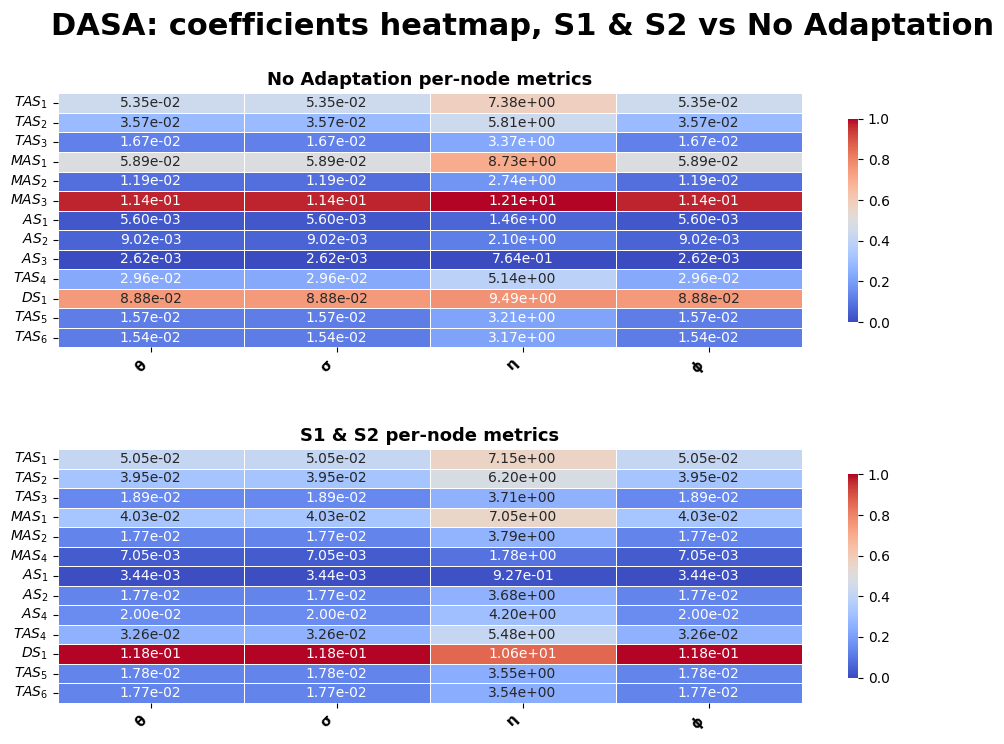

In [9]:
heat_metrics = ["theta", "sigma", "eta", "phi"]
heat_labels = [COEF_LABELS[m] for m in heat_metrics]

# plot_node_heatmap aligns rows positionally (iloc[i]); each panel's y-axis labels come from its own `key` column, so swap-slot rows show baseline's MAS_{3}/AS_{3} and s2/aggregate's MAS_{4}/AS_{4} at the same row position. DS_{1} is constant across all scenarios.
for a in ["s1", "s2", "aggregate"]:
    plot_node_heatmap(
        ndss=[dim_nodes["baseline"], dim_nodes[a]],
        names=[DISPLAY["baseline"], DISPLAY[a]],
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"DASA: coefficients heatmap, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_heatmap_vs_baseline.png")

## 6. Per-node coefficient diffmap (vs baseline)

For every non-baseline adaptation, show the relative change
$(\text{other} - \text{dflt}) / |\text{dflt}|$ per artifact. Diverging
colour scale, zero-centred so improvements and degradations read with equal
intensity.


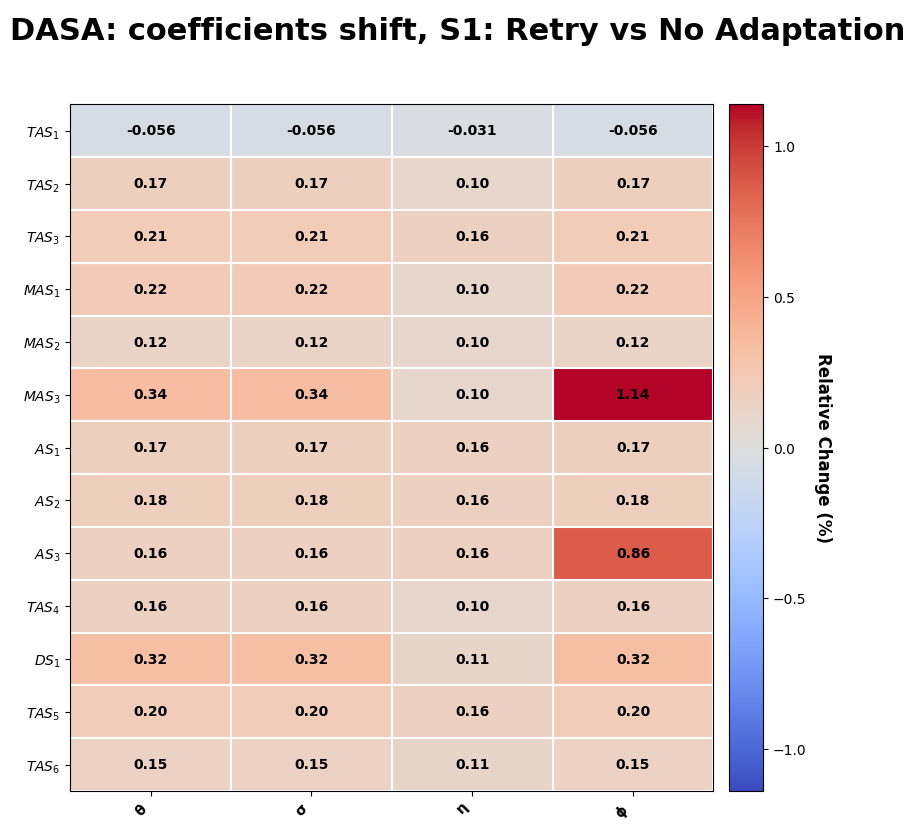

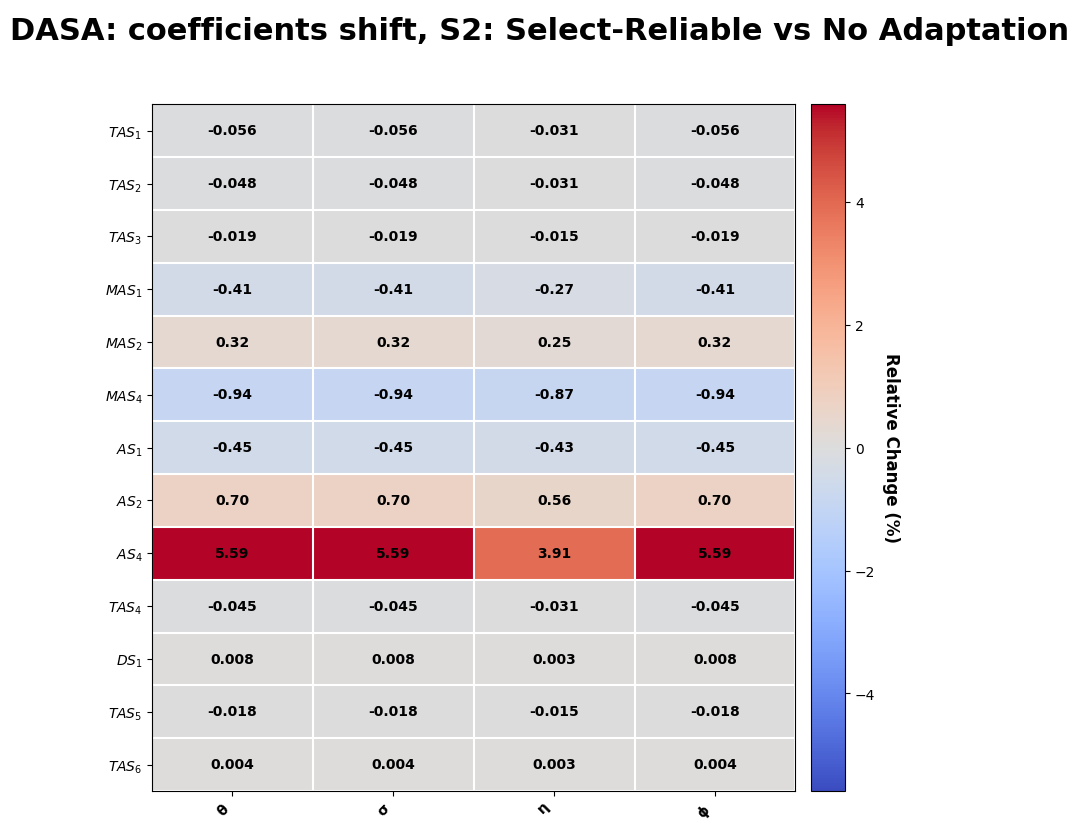

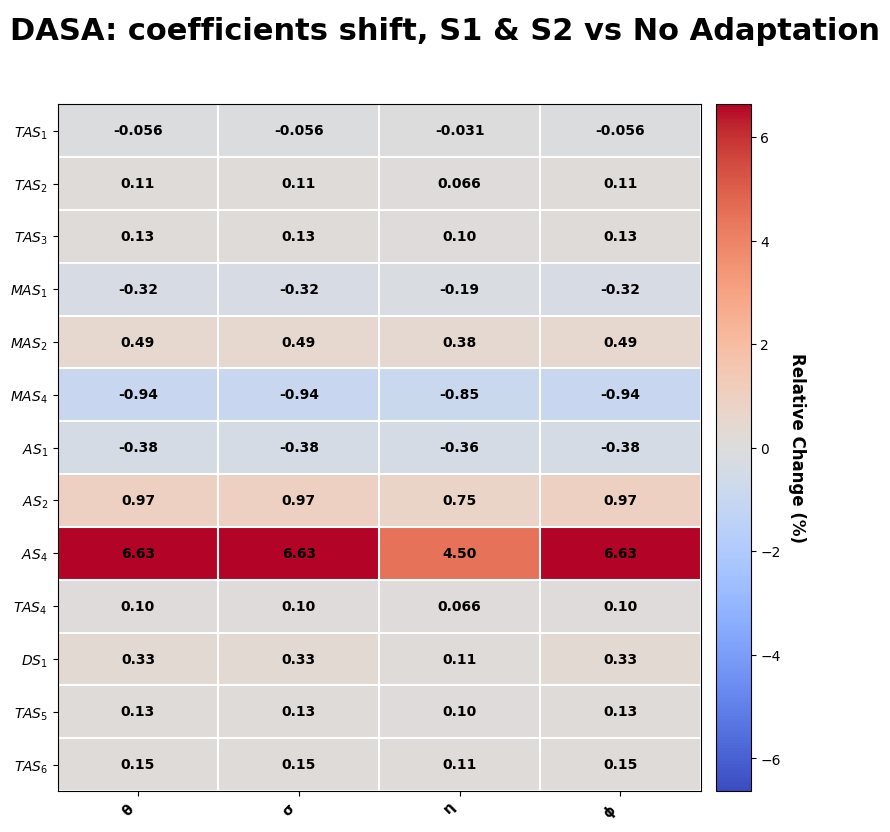

In [10]:
# positional-index inline delta (matches 01-analytic): align by slot since `key` may differ at swap slots
bl_nodes = dim_nodes["baseline"]
for a in ["s1", "s2", "aggregate"]:
    ac_nodes = dim_nodes[a]
    rows = []
    for i in range(len(ac_nodes)):
        b_row = bl_nodes.iloc[i]
        c_row = ac_nodes.iloc[i]
        row = {"key": c_row["key"]}
        for m in heat_metrics:
            b, c = float(b_row[m]), float(c_row[m])
            row[m] = ((c - b) / abs(b)) if b else 0.0
        rows.append(row)
    deltas = pd.DataFrame(rows)

    plot_node_diffmap(
        deltas=deltas,
        nodes=deltas["key"].tolist(),
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"DASA: coefficients shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_diffmap_vs_baseline.png")

## 7. Network-wide coefficient bars

Headline comparison of the four coefficients across all four adaptations.
Linear y-axis (coefficients are O(1)); log scale would be misleading.


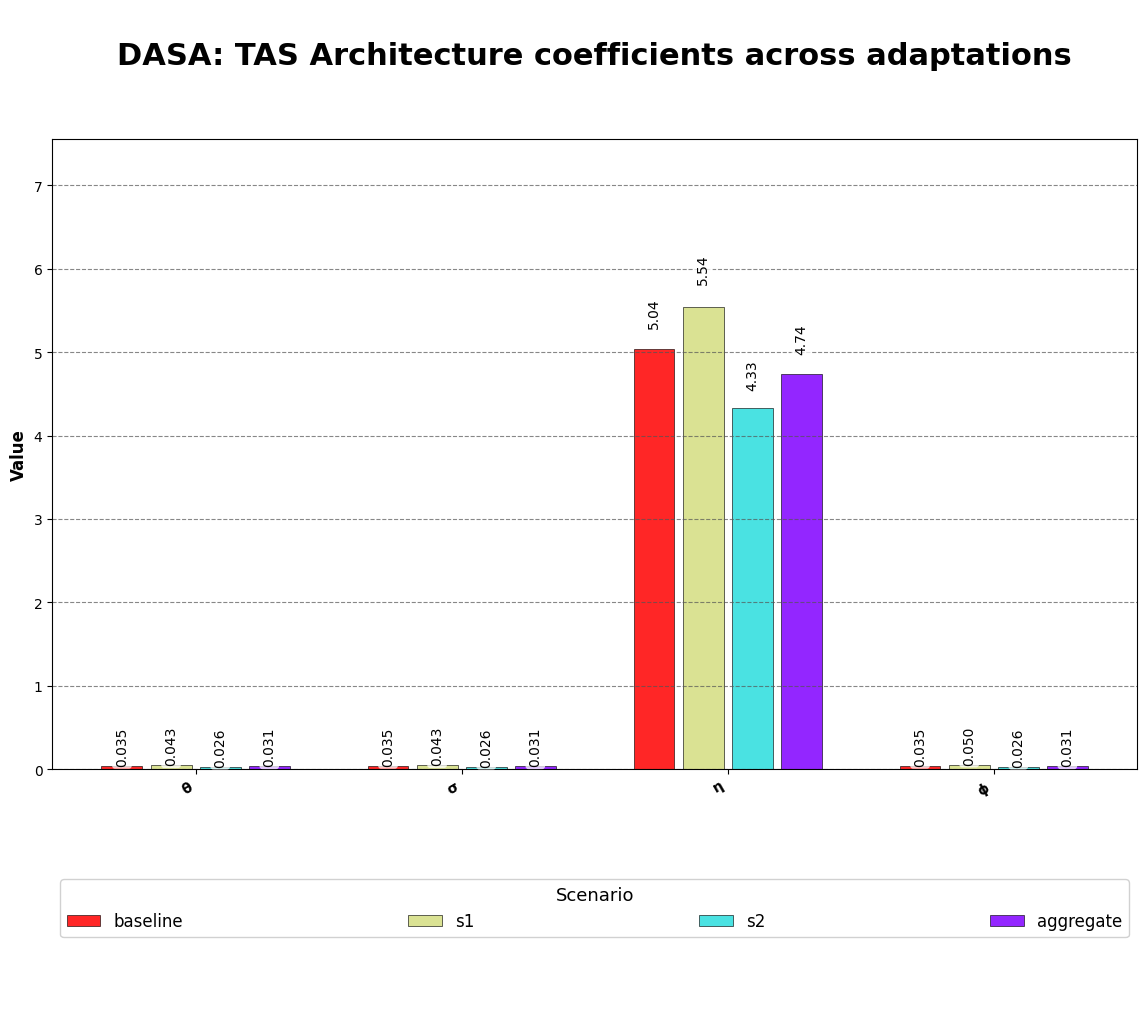

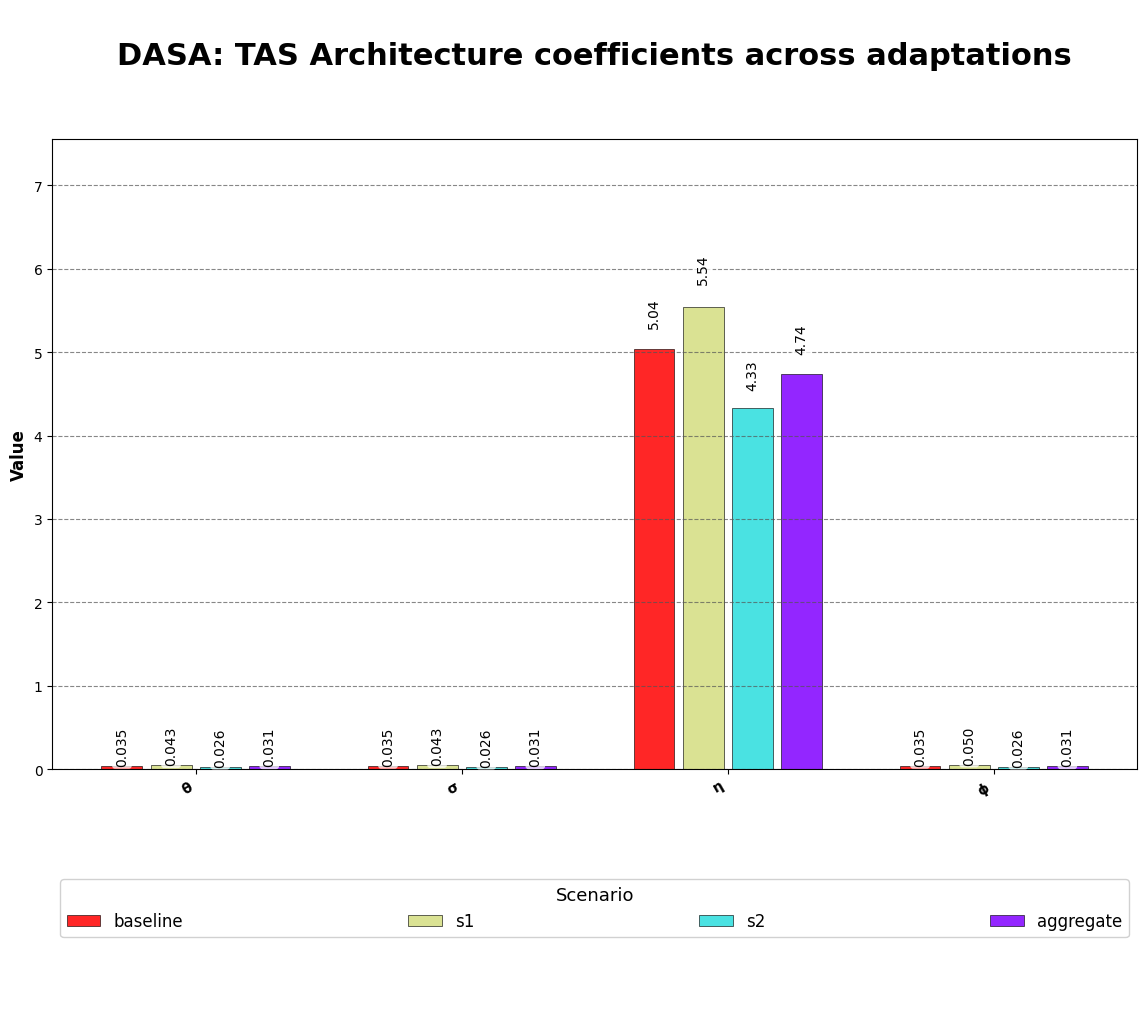

In [11]:
bar_metrics = ["theta", "sigma", "eta", "phi"]
bar_labels = [COEF_LABELS[m] for m in bar_metrics]

plot_arch_bars(
    nets=[dim_nets[a] for a in ADAPTATIONS],
    names=ADAPTATIONS,
    metrics=bar_metrics,
    labels=bar_labels,
    logscale=False,
    title="DASA: TAS Architecture coefficients across adaptations",
    file_path=str(IMG_ROOT / "aggregate"),
    fname="net_bars_all.png",
)

## 8. Network-wide delta (% change vs baseline)

Fractional change for each non-baseline adaptation. Colours semantic: green
when the coefficient decreases (generally an improvement: less occupancy,
less stall, less buffer pressure); red when it increases.


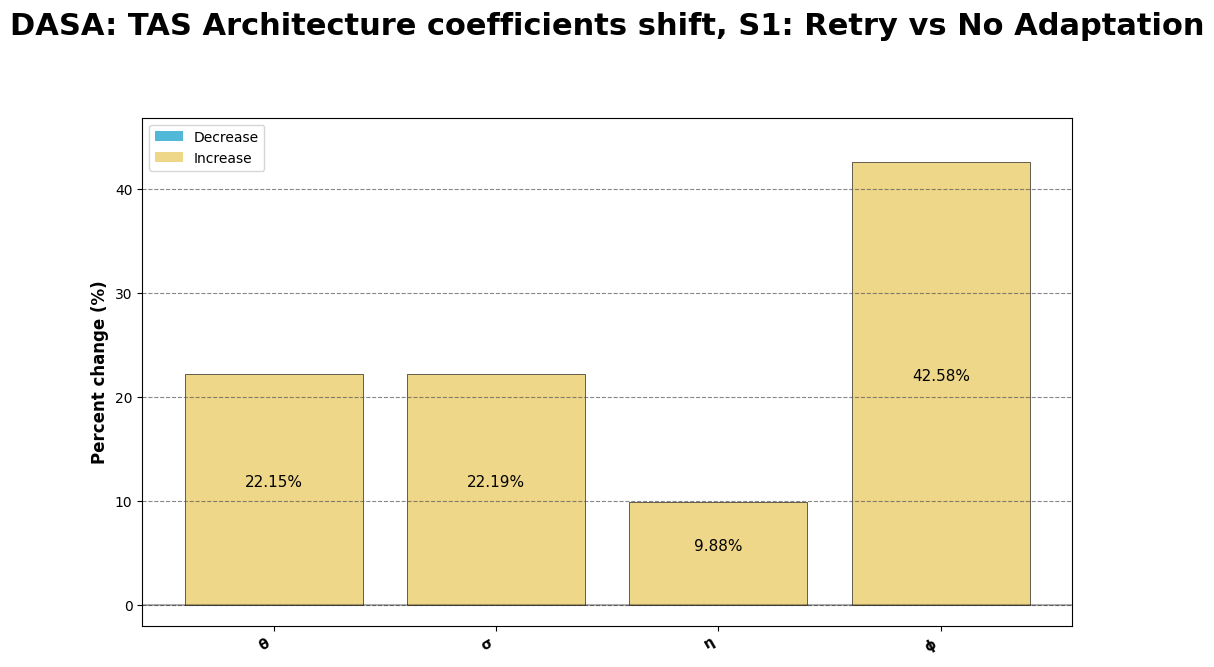

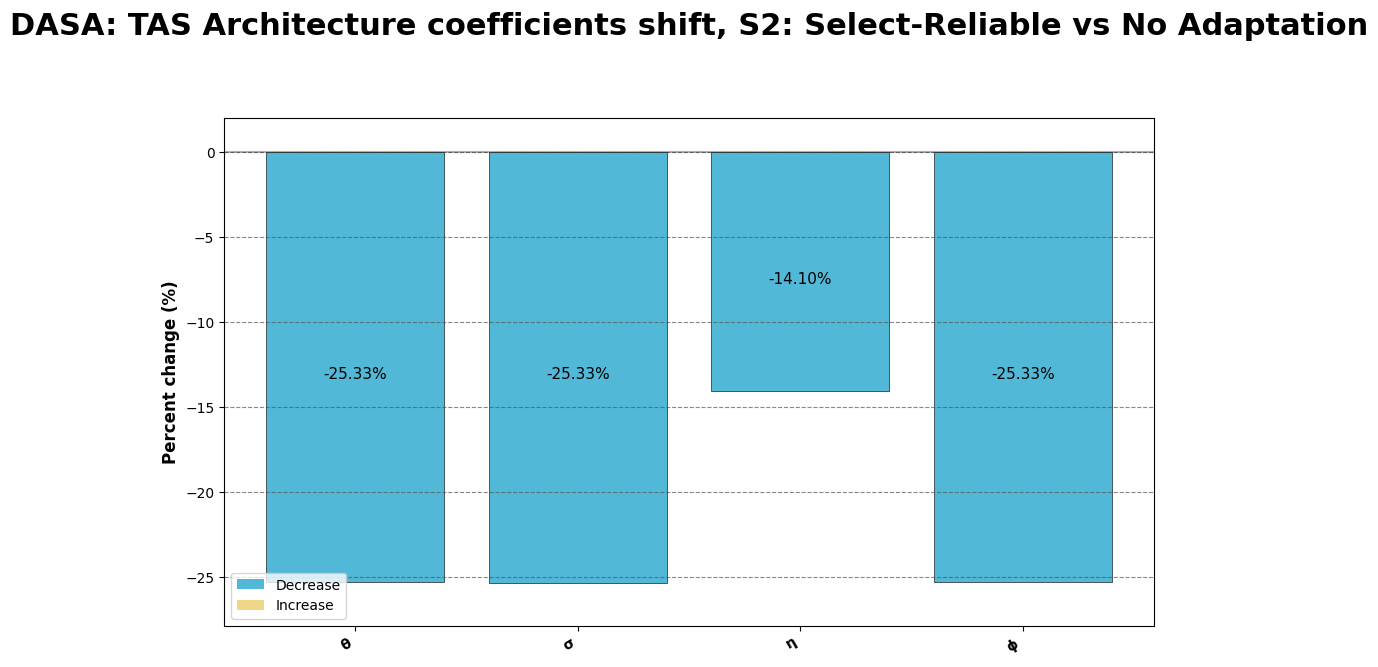

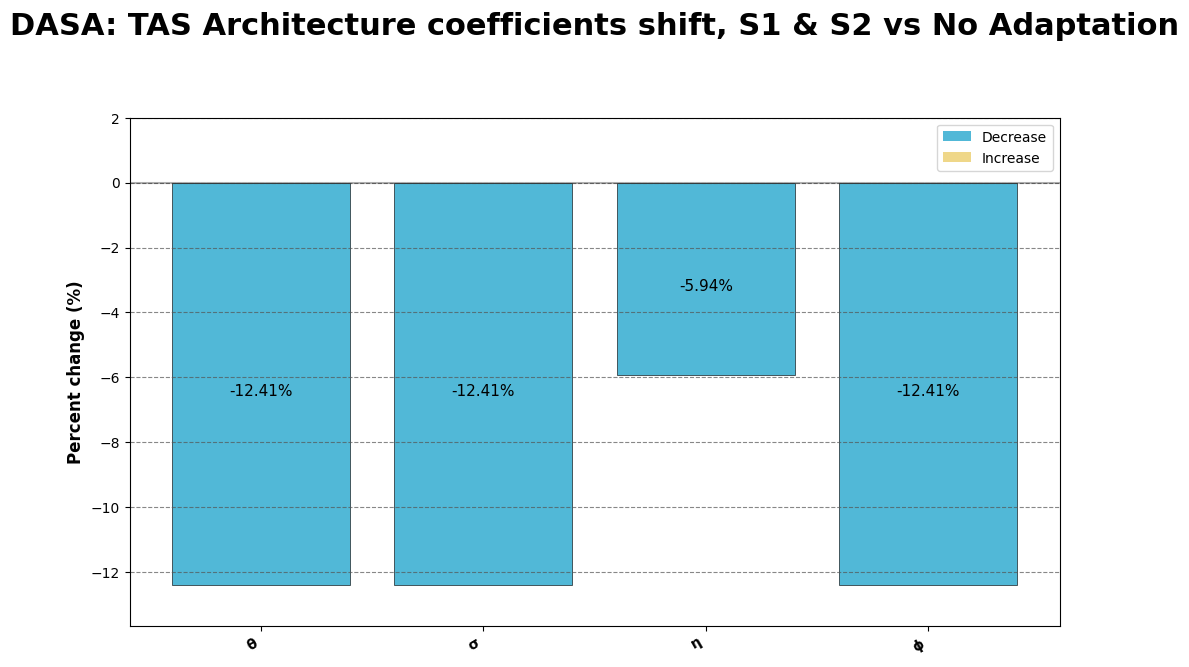

In [12]:
# inline delta-comprehension (matches 01-analytic): one fractional delta per metric per non-baseline adaptation
bl = dim_nets["baseline"].iloc[0]
for a in ["s1", "s2", "aggregate"]:
    ac = dim_nets[a].iloc[0]
    row = {
        m: (ac[m] - bl[m]) / bl[m] if bl[m] else 0.0
        for m in bar_metrics
    }
    plot_arch_delta(
        deltas=pd.DataFrame([row]),
        metrics=bar_metrics,
        labels=bar_labels,
        title=f"DASA: TAS Architecture coefficients shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="net_delta_vs_baseline.png")

## 9. R1 / R2 verdict via dimensional bounds (E-QS validation)

The dimensional method produces R1 / R2 verdicts via Pi-group **bounds** rather than direct operational measurements. Following the DASA modelling derivation (Block 4), the bounds and the architecture-level dimensionless coefficients are:

$$\sigma_{R2} = \frac{W_{R2} \cdot \lambda_z}{K_{\min}}, \qquad \eta_{R1} = \frac{\lambda_z \cdot (1 + \varepsilon_{R1}) \cdot K_{\min}}{\mu_{\min} \cdot c_{\min}}$$

$$\sigma_{\text{arch}} = \frac{W_{\text{e2e}} \cdot \lambda_z}{K_{\min}}, \qquad \eta_{\text{arch}} = \frac{\lambda_z \cdot (1 + \varepsilon_{\text{e2e}}) \cdot K_{\min}}{\mu_{\min} \cdot c_{\min}}$$

The verdict equivalences hold by construction (both sides share the same $\lambda_z / K_{\min}$ and $\lambda_z \cdot K_{\min} / (\mu_{\min} \cdot c_{\min})$ scaling):

- $\sigma_{\text{arch}} < \sigma_{R2}$ $\iff$ $W_{\text{e2e}} < W_{R2}$ $\iff$ **R2 PASS**
- $\eta_{\text{arch}} < \eta_{R1}$ $\iff$ $\varepsilon_{\text{e2e}} < \varepsilon_{R1}$ $\iff$ **R1 PASS**

So the dimensional verdict matches the analytic / stochastic verdicts in §9 of `01-analytic.ipynb` / `02-stochastic.ipynb` exactly. The dimensional view's contribution is **not** a different verdict, but the re-framing of the same threshold check as a viable-region predicate in dimensionless space (the bounds are scale-free under the locked envelope).

The architecture-level operational values $W_{\text{e2e}}$ and $\varepsilon_{\text{e2e}}$ come from the analytic Jackson solution per adaptation under the **loss-network** model: failures are routing leaks absorbed at the `FAIL_{1}` sink, so availability is read from flow:

- $\varepsilon_{\text{e2e}} = \lambda_{\text{FAIL}} / \lambda_z$ (failed fraction; flow absorbed at the FAIL sink)
- $\chi_{\text{out}} = \lambda_z - \lambda_{\text{FAIL}}$ (effective successful-completion rate)
- $W_{\text{e2e}} = L_{\text{net}} / \chi_{\text{out}}$ (per-request end-to-end response time)

**Thresholds and bounds (locked envelope):** $W_{R2} = 26$ ms (Camara 2023, from [`data/reference/baseline.json`](data/reference/baseline.json)); $\varepsilon_{R1} = 0.01$ (Weyns 2015). Denominator parameters are fixed at baseline's worst case ($\lambda_z = 323$ req/s, $K_{\min} = 16$, $\mu_{\min} = 150$ at MAS_{3}, $c_{\min} = 1$) and held constant across adaptations for cross-method comparability (reference-frame caveat in the DASA modelling derivation).

In [13]:
# Bound parameters fixed at baseline's worst case (dasa-modelling.md Block 4 reference frame).
cfg_b = cfgs["baseline"]
LAMBDA_Z = float(cfg_b.build_lam_z_vec()[0])
K_min  = min(a.K for a in cfg_b.artifacts)
mu_min = min(a.mu for a in cfg_b.artifacts)
c_min  = min(a.c for a in cfg_b.artifacts)

# R1 / R2 thresholds (pulled from the per-adaptation verdict; same across adaptations).
W_R2   = reqs["baseline"]["R2"]["threshold"]  # s
EPS_R1 = reqs["baseline"]["R1"]["threshold"]  # fraction

# Fixed-frame dimensional bounds.
SIGMA_R2 = W_R2 * LAMBDA_Z / K_min
ETA_R1   = LAMBDA_Z * (1 + EPS_R1) * K_min / (mu_min * c_min)

# Per-adaptation summary — same column order as 01-analytic.ipynb / 02-stochastic.ipynb,
# with the dimensional sigma_arch / eta_arch comparison inserted between the operational
# metrics and the R1 / R2 verdict.
verdict_rows = []
for a in ADAPTATIONS:
    n = nets[a].iloc[0]
    r = reqs[a]
    W_e2e   = float(n["W_e2e"])
    eps_e2e = float(n["eps_e2e"])
    sigma_arch = W_e2e * LAMBDA_Z / K_min
    eta_arch   = LAMBDA_Z * (1 + eps_e2e) * K_min / (mu_min * c_min)
    verdict_rows.append({
        "adaptation": a,
        "profile": cfgs[a].profile,
        r"$\mathbf{W_{e2e}}$ [ms]": W_e2e * 1000,
        r"$\mathbf{\varepsilon_{e2e}}$ [%]": eps_e2e * 100,
        r"$\mathbf{\overline{\rho}_{TAS}}$": n["avg_rho"],
        r"$\mathbf{\rho_{TAS,\,Max}}$": n["max_rho"],
        r"$\mathbf{L_{net}}$": n["L_net"],
        r"$\mathbf{\sigma_{arch}}$": sigma_arch,
        r"$\mathbf{\sigma_{R2}}$":   SIGMA_R2,
        r"$\mathbf{\eta_{arch}}$":   eta_arch,
        r"$\mathbf{\eta_{R1}}$":     ETA_R1,
        "R1 (≤ 1.0%)": "PASS" if r["R1"]["pass"] else "FAIL",
        "R2 (≤ 26 ms)": "PASS" if r["R2"]["pass"] else "FAIL",
    })
summary = pd.DataFrame(verdict_rows).set_index("adaptation")
summary.round(4)

,profile,$\mathbf{W_{e2e}}$ [ms],$\mathbf{\varepsilon_{e2e}}$ [%],$\mathbf{\overline{\rho}_{TAS}}$,"$\mathbf{\rho_{TAS,\,Max}}$",$\mathbf{L_{net}}$,$\mathbf{\sigma_{arch}}$,$\mathbf{\sigma_{R2}}$,$\mathbf{\eta_{arch}}$,$\mathbf{\eta_{R1}}$,R1 (≤ 1.0%),R2 (≤ 26 ms)
adaptation,,,,,,,,,,,,
baseline,dflt,25.7402,14.8216,0.2927,0.6499,7.0818,0.5275,0.5329,39.4355,34.6885,FAIL,PASS
s1,opti,27.7147,0.2048,0.3218,0.7167,8.6569,0.5680,0.5329,34.4154,34.6885,PASS,FAIL
s2,opti,18.5294,10.4216,0.2562,0.5685,5.1953,0.3798,0.5329,37.9243,34.6885,FAIL,PASS
aggregate,opti,19.4013,0.0714,0.2806,0.6318,6.0683,0.3976,0.5329,34.3695,34.6885,PASS,PASS


## Summary

Dimensional analysis produces the same four derived coefficients per artifact under every adaptation. **Pi-group expressions are invariant** across adaptations (same variable set, different setpoints); this is the Buckingham guarantee.

§9 delivers the **R1 / R2 verdict via dimensional bounds** ($\sigma_{R2} \approx 0.525$ and $\eta_{R1} \approx 34.80$ from the DASA modelling derivation (Block 4) at the locked envelope $\lambda_z = 323$ req/s, $K_{\min} = 16$). The architecture-level coefficients $\sigma_{\text{arch}}$ and $\eta_{\text{arch}}$ are derived from the operational $W_{\text{e2e}}$ and $\varepsilon_{\text{e2e}}$ (loss-network flow, `eps_e2e = lambda_FAIL/lambda_z`; see §9 of `01-analytic.ipynb`), so the dimensional verdict matches the analytic verdict by construction. The dimensional view's contribution is the re-framing of the same threshold check as a **viable-region predicate in dimensionless space**, and the result is the performance-vs-availability trade-off:

- **R1 (Availability) viable region:** baseline and S2 fall outside it ($\eta_{\text{arch}} = 39.6 / 38.0 > \eta_{R1} = 34.8$; $\varepsilon_{\text{e2e}} = 14.8\% / 10.4\%$, catalogue-bound). S1 and the aggregate sit inside ($\eta_{\text{arch}} = 34.5 / 34.5$; $\varepsilon_{\text{e2e}} = 0.2\% / 0.07\%$): retry recovers availability multiplicatively (residual $\sim f^k$).
- **R2 (Performance) viable region:** baseline, S2, and the aggregate sit inside ($\sigma_{\text{arch}} = 0.52 / 0.37 / 0.39 < \sigma_{R2} = 0.52$). S1 falls just outside ($\sigma_{\text{arch}} = 0.56$; $W_{\text{e2e}} = 27.7$ ms): retry re-dispatch overloads the MAS / AS pools.

Only the **aggregate** (Select-Reliable + Retry) sits inside both viable regions. Configuration-sweep yoly diagrams (the full coefficient cloud across a $(\mu, c, K)$ grid) live in `04-yoly.ipynb`. Cross-method triangulation (analytic vs stochastic vs dimensional) lands in the comparison notebook downstream.